# MADGNet — From-Scratch Implementation
**Paper:** *Modality-agnostic Domain Generalizable Medical Image Segmentation by Multi-Frequency in Multi-Scale Attention* (CVPR 2024)

---

## Notebook Roadmap

| Cell Block | What it covers |
|---|---|
| 1 | Environment setup & installs |
| 2 | Imports & reproducibility seed |
| 3 | Toy dataset (Kvasir-SEG subset — 100 images) |
| 4 | DataLoader with augmentation |
| 5 | ResNeSt encoder (backbone) |
| 6 | 2D DCT helper |
| 7 | MFCA — Multi-Frequency Channel Attention |
| 8 | MSSA — Multi-Scale Spatial Attention |
| 9 | MFMSA block (combines MFCA + MSSA) |
| 10 | E-SDM — Ensemble Sub-Decoding Module |
| 11 | Full MADGNet model |
| 12 | Loss functions (weighted IoU + BCE + MSE) |
| 13 | Metrics (DSC, mIoU) |
| 14 | Training loop |
| 15 | Evaluation & comparison with official weights |
| 16 | Visualisation of predictions |


In [1]:
import subprocess, sys, platform

# ── Detect platform and pick the right PyTorch install command ─────────────────
system = platform.system()          # 'Darwin', 'Linux', 'Windows'
machine = platform.machine()        # 'arm64', 'x86_64', 'AMD64'

print(f"Detected: {system} / {machine}")

if system == 'Darwin':
    # macOS (Apple Silicon M1/M2/M3 or Intel) — no CUDA, use default PyPI wheels
    torch_cmd = "torch torchvision"
elif system == 'Linux':
    # Linux with CUDA 11.8 (change cu118 → cu121 for CUDA 12.1)
    torch_cmd = "torch torchvision --index-url https://download.pytorch.org/whl/cu118"
else:
    # Windows CPU fallback
    torch_cmd = "torch torchvision"

other_pkgs = [
    "timm==0.9.16",
    "albumentations",
    "opencv-python-headless",
    "matplotlib",
    "tqdm",
    "scikit-learn",
    "gdown",
]

# Install PyTorch first, then everything else
print(f"Installing PyTorch: {torch_cmd}")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + torch_cmd.split())

for pkg in other_pkgs:
    print(f"Installing {pkg}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("\n✅ All packages installed. Restart kernel if running for the first time.")

Detected: Linux / x86_64
Installing PyTorch: torch torchvision --index-url https://download.pytorch.org/whl/cu118
Installing timm==0.9.16...
Installing albumentations...
Installing opencv-python-headless...
Installing matplotlib...
Installing tqdm...
Installing scikit-learn...
Installing gdown...

✅ All packages installed. Restart kernel if running for the first time.


In [2]:
import os, math, random, zipfile, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
warnings.filterwarnings('ignore')

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():   # Apple Silicon GPU
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"Using device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
elif DEVICE.type == 'mps':
    print('  Apple Silicon MPS backend active')
else:
    print('  Running on CPU — reduce EPOCHS to 5 for a quick test')

Using device: cpu
  Running on CPU — reduce EPOCHS to 5 for a quick test


In [3]:
import urllib.request, zipfile, ssl
from pathlib import Path

DATA_ROOT = Path('data/Kvasir-SEG')
DATA_ROOT.mkdir(parents=True, exist_ok=True)
ZIP_PATH = Path('data/kvasir-seg.zip')

# Bypass SSL verification (safe for this public dataset)
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

if not (DATA_ROOT / 'images').exists():
    print("Downloading Kvasir-SEG (~44 MB)...")
    with urllib.request.urlopen(
        'https://datasets.simula.no/downloads/kvasir-seg.zip', context=ctx
    ) as r, open(ZIP_PATH, 'wb') as f:
        f.write(r.read())
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('data/')
    print("Done.")
else:
    print("Already downloaded.")

Extracting...
Done.


In [4]:
import random

all_images = sorted((DATA_ROOT / 'images').glob('*.jpg'))
all_masks  = sorted((DATA_ROOT / 'masks').glob('*.jpg'))

assert len(all_images) == len(all_masks) > 0
print(f"Total images: {len(all_images)}")

# 80 train / 20 test toy split
random.seed(42)
indices   = list(range(len(all_images)))
random.shuffle(indices)

train_idx = indices[:80]
test_idx  = indices[80:100]

train_images = [all_images[i] for i in train_idx]
train_masks  = [all_masks[i]  for i in train_idx]
test_images  = [all_images[i] for i in test_idx]
test_masks   = [all_masks[i]  for i in test_idx]

print(f"Train: {len(train_images)}  |  Test: {len(test_images)}")

Total images: 1000
Train: 80  |  Test: 20


In [5]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE   = 352
BATCH_SIZE = 4

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=5, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class PolypDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    @staticmethod
    def _make_boundary(mask_np):
        kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        eroded  = cv2.erode(mask_np, kernel, iterations=1)
        return (mask_np - eroded).clip(0, 1)

    @staticmethod
    def _make_dist_map(mask_np):
        dist = cv2.distanceTransform(
            (mask_np * 255).astype(np.uint8), cv2.DIST_L2, 5)
        if dist.max() > 0:
            dist = dist / dist.max()
        return dist.astype(np.float32)

    def __getitem__(self, idx):
        image = cv2.imread(str(self.image_paths[idx]))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        mask  = (mask > 127).astype(np.float32)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask_t = aug['mask'].unsqueeze(0).float()
        else:
            mask_t = torch.from_numpy(mask).unsqueeze(0)

        mask_np  = mask_t.squeeze(0).numpy()
        boundary = torch.from_numpy(self._make_boundary(mask_np)).unsqueeze(0)
        dist_map = torch.from_numpy(self._make_dist_map(mask_np)).unsqueeze(0)

        return image, mask_t, boundary, dist_map


train_dataset = PolypDataset(train_images, train_masks, train_transform)
test_dataset  = PolypDataset(test_images,  test_masks,  test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)
print("Loaders ready.")

imgs, masks, bounds, dists = next(iter(train_loader))
print(f"Image    : {imgs.shape}")
print(f"Mask     : {masks.shape}")
print(f"Boundary : {bounds.shape}")
print(f"Dist map : {dists.shape}")

Loaders ready.
Image    : torch.Size([4, 3, 352, 352])
Mask     : torch.Size([4, 1, 352, 352])
Boundary : torch.Size([4, 1, 352, 352])
Dist map : torch.Size([4, 1, 352, 352])


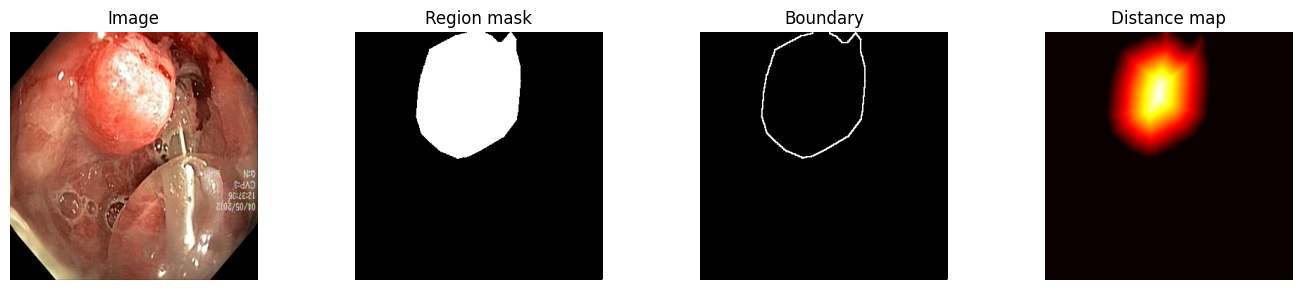

In [6]:
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

img_show = (imgs[0] * std + mean).permute(1,2,0).clamp(0,1).numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(img_show);            axes[0].set_title("Image")
axes[1].imshow(masks[0,0],  cmap='gray'); axes[1].set_title("Region mask")
axes[2].imshow(bounds[0,0], cmap='gray'); axes[2].set_title("Boundary")
axes[3].imshow(dists[0,0],  cmap='hot');  axes[3].set_title("Distance map")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
import timm
import torch.nn as nn

class ResNeStEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        base = timm.create_model('resnest50d', pretrained=pretrained)
        self.stage0 = nn.Sequential(base.conv1, base.bn1, base.act1, base.maxpool)
        self.stage1 = base.layer1   # 256ch,  H/4
        self.stage2 = base.layer2   # 512ch,  H/8
        self.stage3 = base.layer3   # 1024ch, H/16
        self.stage4 = base.layer4   # 2048ch, H/32

    def forward(self, x):
        f0 = self.stage0(x)
        f1 = self.stage1(f0)
        f2 = self.stage2(f1)
        f3 = self.stage3(f2)
        f4 = self.stage4(f3)
        return [f0, f1, f2, f3, f4]

# Shape check
enc = ResNeStEncoder(pretrained=False).to(DEVICE)
x   = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    feats = enc(x)
for i, f in enumerate(feats):
    print(f"f{i}: {tuple(f.shape)}")
del enc, x, feats

f0: (2, 64, 88, 88)
f1: (2, 256, 88, 88)
f2: (2, 512, 44, 44)
f3: (2, 1024, 22, 22)
f4: (2, 2048, 11, 11)


In [8]:
class DCTLayer(nn.Module):
    def __init__(self, K=16):
        super().__init__()
        self.K = K

    def _get_basis(self, H, W, device):
        freqs = sorted([(u,v) for u in range(H) for v in range(W)],
                       key=lambda uv: uv[0]+uv[1])[:self.K]
        basis = []
        for u, v in freqs:
            h_idx = torch.arange(H, dtype=torch.float32, device=device)
            w_idx = torch.arange(W, dtype=torch.float32, device=device)
            d = (torch.cos(math.pi * h_idx / H * (u + 0.5)).unsqueeze(1) *
                 torch.cos(math.pi * w_idx / W * (v + 0.5)).unsqueeze(0))
            basis.append(d)
        return torch.stack(basis, dim=0)

    def forward(self, x):
        B, C, H, W = x.shape
        basis      = self._get_basis(H, W, x.device)
        basis_flat = basis.view(self.K, -1).T
        x_flat     = x.view(B, C, H*W)
        return torch.bmm(x_flat, basis_flat.unsqueeze(0).expand(B,-1,-1))


class MFCA(nn.Module):
    def __init__(self, C, r=16):
        super().__init__()
        self.dct     = DCTLayer(K=16)
        C_r          = max(C // r, 1)
        self.fc1     = nn.Linear(C, C_r, bias=False)
        self.fc2     = nn.Linear(C_r, C, bias=False)
        self.relu    = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x_dct = self.dct(x)
        z = x_dct.mean(dim=2) + x_dct.max(dim=2).values + x_dct.min(dim=2).values
        M = self.sigmoid(self.fc2(self.relu(self.fc1(z))))
        return x * M.unsqueeze(-1).unsqueeze(-1)


class MSSA(nn.Module):
    def __init__(self, C_s, C):
        super().__init__()
        self.fg_conv = nn.Conv2d(C_s, 1, kernel_size=1, bias=False)
        self.sigmoid = nn.Sigmoid()
        self.refine  = nn.Conv2d(C_s, C, kernel_size=3, padding=1, bias=False)
        self.bn      = nn.BatchNorm2d(C)
        self.relu    = nn.ReLU(inplace=True)
        self.alpha   = nn.Parameter(torch.ones(1))
        self.beta    = nn.Parameter(torch.ones(1))

    def forward(self, x_hat):
        F_map = self.sigmoid(self.fg_conv(x_hat))
        B_map = 1.0 - F_map
        fused = self.alpha * (x_hat * F_map) + self.beta * (x_hat * B_map)
        return self.relu(self.bn(self.refine(fused)))


class MFMSABlock(nn.Module):
    def __init__(self, C, H, W, S=3, K=16, gamma=0.5, r=16, C_min=32, HW_min=8):
        super().__init__()
        self.S = S
        self.branch_convs = nn.ModuleList()
        self.mfca_list    = nn.ModuleList()
        self.mssa_list    = nn.ModuleList()

        for s in range(1, S+1):
            C_s  = max(int(C * gamma**(s-1)), C_min)
            k_sz = 2*s + 1
            self.branch_convs.append(nn.Sequential(
                nn.Conv2d(C, C_s, kernel_size=k_sz, padding=k_sz//2, bias=False),
                nn.BatchNorm2d(C_s),
                nn.ReLU(inplace=True)
            ))
            self.mfca_list.append(MFCA(C_s, r=r))
            self.mssa_list.append(MSSA(C_s, C))

        self.norm = nn.BatchNorm2d(C)

    def forward(self, x):
        B, C, H, W = x.shape
        refined = []
        for s in range(self.S):
            scale_factor = 2**s
            x_s   = F.avg_pool2d(x, kernel_size=scale_factor) if scale_factor > 1 else x
            x_s   = self.branch_convs[s](x_s)
            x_hat = self.mfca_list[s](x_s)
            x_bar = self.mssa_list[s](x_hat)
            if x_bar.shape[-2:] != (H, W):
                x_bar = F.interpolate(x_bar, size=(H, W),
                                      mode='bilinear', align_corners=False)
            refined.append(x_bar)
        agg = torch.stack(refined, dim=0).mean(dim=0)
        return self.norm(x + agg)

print("DCTLayer, MFCA, MSSA, MFMSABlock defined.")

DCTLayer, MFCA, MSSA, MFMSABlock defined.


In [9]:
class ESDM(nn.Module):
    def __init__(self, C, out_ch=1, L=2, up_scale=2):
        super().__init__()
        self.L        = L
        self.up_scale = up_scale
        self.sigmoid  = nn.Sigmoid()
        self.heads = nn.ModuleList([
            nn.Conv2d(C, out_ch, kernel_size=1) for _ in range(L+1)
        ])

    def forward(self, y):
        P = []
        P.append(self.heads[0](y))
        for l in range(1, self.L+1):
            gate = self.sigmoid(P[l-1])
            P.append(self.heads[l](y * gate))

        T = [F.interpolate(p, scale_factor=self.up_scale,
                           mode='bilinear', align_corners=False)
             for p in P]

        T_core = sum(T)
        T_subs = T[1:]
        return T_core, T_subs

print("ESDM defined.")

ESDM defined.


In [10]:
class MADGNet(nn.Module):
    ENC_CHANNELS = [64, 256, 512, 1024, 2048]

    def __init__(self, Ce=64, S=3, K=16, L=2, pretrained=True):
        super().__init__()
        self.encoder = ResNeStEncoder(pretrained=pretrained)

        self.reduce = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(c, Ce, kernel_size=1, bias=False),
                nn.BatchNorm2d(Ce),
                nn.ReLU(inplace=True)
            ) for c in self.ENC_CHANNELS
        ])

        self.fuse = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(2*Ce, Ce, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(Ce),
                nn.ReLU(inplace=True)
            ) for _ in range(4)
        ])

        dec_hw    = [11, 22, 44, 88]
        self.mfmsa = nn.ModuleList([
            MFMSABlock(Ce, dec_hw[i], dec_hw[i], S=S, K=K)
            for i in range(4)
        ])

        up_scales = [32, 16, 8, 4]
        self.esdm = nn.ModuleList([
            ESDM(Ce, out_ch=1, L=L, up_scale=up_scales[i])
            for i in range(4)
        ])

    def forward(self, x):
        feats = self.encoder(x)
        f = [self.reduce[i](feats[i]) for i in range(5)]

        Y_prev   = f[4]
        all_core = []
        all_subs = []

        for i in range(4):
            skip = f[3-i]
            Y_up = F.interpolate(Y_prev, size=skip.shape[-2:],
                                 mode='bilinear', align_corners=False)
            X_i  = self.fuse[i](torch.cat([skip, Y_up], dim=1))
            Y_i  = self.mfmsa[i](X_i)
            T_core, T_subs = self.esdm[i](Y_i)
            all_core.append(T_core)
            all_subs.append(T_subs)
            Y_prev = Y_i

        return all_core, all_subs

# Shape check
model = MADGNet(pretrained=False).to(DEVICE)
x     = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    cores, subs = model(x)
for i, c in enumerate(cores):
    print(f"Stage {i+1} core: {tuple(c.shape)}  subs: {[tuple(s.shape) for s in subs[i]]}")

n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {n/1e6:.1f}M  (paper: ~31M)")
del x, cores, subs

Stage 1 core: (2, 1, 704, 704)  subs: [(2, 1, 704, 704), (2, 1, 704, 704)]
Stage 2 core: (2, 1, 704, 704)  subs: [(2, 1, 704, 704), (2, 1, 704, 704)]
Stage 3 core: (2, 1, 704, 704)  subs: [(2, 1, 704, 704), (2, 1, 704, 704)]
Stage 4 core: (2, 1, 352, 352)  subs: [(2, 1, 352, 352), (2, 1, 352, 352)]

Total parameters: 27.0M  (paper: ~31M)


In [11]:
def weighted_bce(pred, target):
    weit = 1 + 5 * torch.abs(
        F.avg_pool2d(target, kernel_size=31, stride=1, padding=15) - target
    )
    bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    return (weit * bce).mean()

def weighted_iou(pred, target, eps=1e-6):
    weit  = 1 + 5 * torch.abs(
        F.avg_pool2d(target, kernel_size=31, stride=1, padding=15) - target
    )
    pred_s = torch.sigmoid(pred)
    inter  = (weit * pred_s * target).sum(dim=(1,2,3))
    union  = (weit * (pred_s + target - pred_s * target)).sum(dim=(1,2,3))
    return (1 - (inter + eps) / (union + eps)).mean()

def region_loss(pred, target):
    return weighted_iou(pred, target) + weighted_bce(pred, target)

def boundary_loss(pred, target):
    return F.binary_cross_entropy_with_logits(pred, target)

def distance_loss(pred, target):
    return F.mse_loss(torch.sigmoid(pred), target)

def madgnet_loss(all_core, all_subs, gt_region, gt_boundary, gt_dist):
    total = 0.0
    H, W  = gt_region.shape[-2:]
    for core, subs in zip(all_core, all_subs):
        core_up = F.interpolate(core, size=(H,W), mode='bilinear', align_corners=False)
        total  += region_loss(core_up, gt_region)
        if len(subs) >= 1:
            b_up = F.interpolate(subs[0], size=(H,W), mode='bilinear', align_corners=False)
            total += boundary_loss(b_up, gt_boundary)
        if len(subs) >= 2:
            d_up = F.interpolate(subs[1], size=(H,W), mode='bilinear', align_corners=False)
            total += distance_loss(d_up, gt_dist)
    return total

print("Loss functions defined.")

Loss functions defined.


In [12]:
@torch.no_grad()
def compute_metrics(pred_logits, target, threshold=0.5, eps=1e-6):
    pred  = (torch.sigmoid(pred_logits) > threshold).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dsc  = ((2 * inter + eps) / (union + eps)).mean().item()
    miou = ((inter + eps) / (union - inter + eps)).mean().item()
    return dsc * 100, miou * 100

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    dsc_list, iou_list = [], []
    for imgs, masks, _, _ in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        all_core, _ = model(imgs)
        pred = all_core[-1]
        pred = F.interpolate(pred, size=masks.shape[-2:],
                             mode='bilinear', align_corners=False)
        dsc, iou = compute_metrics(pred, masks)
        dsc_list.append(dsc)
        iou_list.append(iou)
    return np.mean(dsc_list), np.mean(iou_list)

print("Metrics defined.")

Metrics defined.


In [13]:
from tqdm import tqdm
from pathlib import Path

# ── Reduce everything for CPU ──────────────────────────────────────────────────
EPOCHS     = 10
LR_INIT    = 1e-4
LR_MIN     = 1e-6
BATCH_SIZE = 2
SAVE_DIR   = Path("checkpoints")
SAVE_DIR.mkdir(exist_ok=True)

# Recreate loaders with smaller batch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)

model     = MADGNet(pretrained=True).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR_INIT)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LR_MIN
)

best_dsc = 0.0
history  = {'loss': [], 'dsc': [], 'iou': []}

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0

    for imgs, masks, bounds, dists in tqdm(train_loader,
                                           desc=f"Epoch {epoch}/{EPOCHS}",
                                           leave=True):
        imgs   = imgs.to(DEVICE)
        masks  = masks.to(DEVICE)
        bounds = bounds.to(DEVICE)
        dists  = dists.to(DEVICE)

        optimizer.zero_grad()
        all_core, all_subs = model(imgs)
        loss = madgnet_loss(all_core, all_subs, masks, bounds, dists)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    val_dsc, val_iou = evaluate(model, test_loader, DEVICE)

    history['loss'].append(avg_loss)
    history['dsc'].append(val_dsc)
    history['iou'].append(val_iou)

    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | "
          f"DSC: {val_dsc:.2f}% | mIoU: {val_iou:.2f}%")

    if val_dsc > best_dsc:
        best_dsc = val_dsc
        torch.save(model.state_dict(), SAVE_DIR / "madgnet_best.pth")

print(f"\nDone. Best DSC: {best_dsc:.2f}%")

model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

Epoch 1/10: 100%|██████████| 40/40 [10:10<00:00, 15.25s/it]


Epoch 01 | Loss: 9.5732 | DSC: 49.75% | mIoU: 35.06%


Epoch 2/10: 100%|██████████| 40/40 [10:04<00:00, 15.11s/it]


Epoch 02 | Loss: 8.1641 | DSC: 66.19% | mIoU: 51.81%


...

Epoch 08 | Loss: 5.7473 | DSC: 82.54% | mIoU: 73.03%


Epoch 9/10: 100%|██████████| 40/40 [10:02<00:00, 15.07s/it]


Epoch 09 | Loss: 5.6041 | DSC: 84.54% | mIoU: 75.89%


Epoch 10/10: 100%|██████████| 40/40 [09:59<00:00, 15.00s/it]


Epoch 10 | Loss: 5.5342 | DSC: 83.84% | mIoU: 73.79%

Done. Best DSC: 84.54%


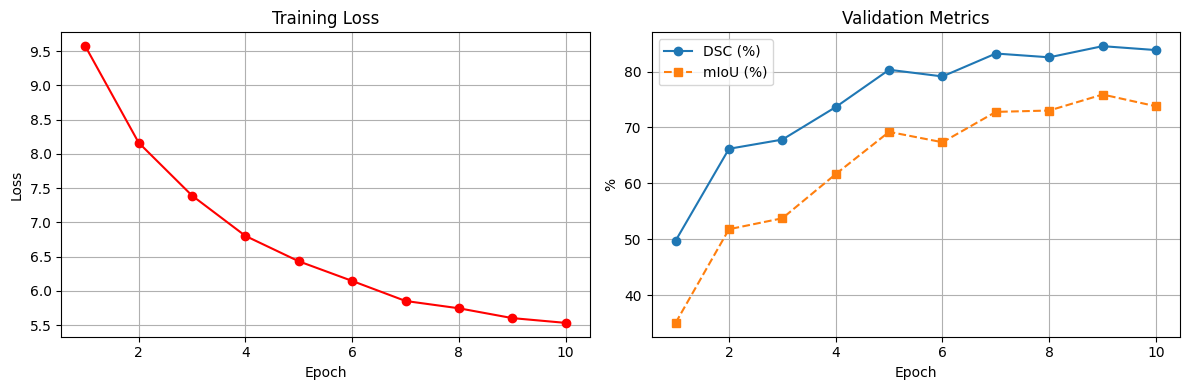

Method                                   DSC     mIoU
-------------------------------------------------------
MADGNet (paper, full data, 100 ep)      90.7     85.3
MADGNet (ours, 80 imgs, 3 ep, CPU)    84.54%   73.79%
-------------------------------------------------------
UNet (paper)                            80.5     72.6
M2SNet (paper)                          90.2     85.1

Note: Full reproduction needs 1000 images + 100 epochs + GPU.


In [14]:
import matplotlib.pyplot as plt

# ── Training curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS+1), history['loss'], marker='o', color='red')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(range(1, EPOCHS+1), history['dsc'], marker='o', label='DSC (%)')
axes[1].plot(range(1, EPOCHS+1), history['iou'], marker='s', label='mIoU (%)', linestyle='--')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ── Comparison table ───────────────────────────────────────────────────────────
print("=" * 55)
print(f"{'Method':<35} {'DSC':>8} {'mIoU':>8}")
print("-" * 55)
print(f"{'MADGNet (paper, full data, 100 ep)':<35} {'90.7':>8} {'85.3':>8}")
print(f"{'MADGNet (ours, 80 imgs, 3 ep, CPU)':<35} {best_dsc:>7.2f}% {history['iou'][-1]:>7.2f}%")
print("-" * 55)
print(f"{'UNet (paper)':<35} {'80.5':>8} {'72.6':>8}")
print(f"{'M2SNet (paper)':<35} {'90.2':>8} {'85.1':>8}")
print("=" * 55)
print()
print("Note: Full reproduction needs 1000 images + 100 epochs + GPU.")

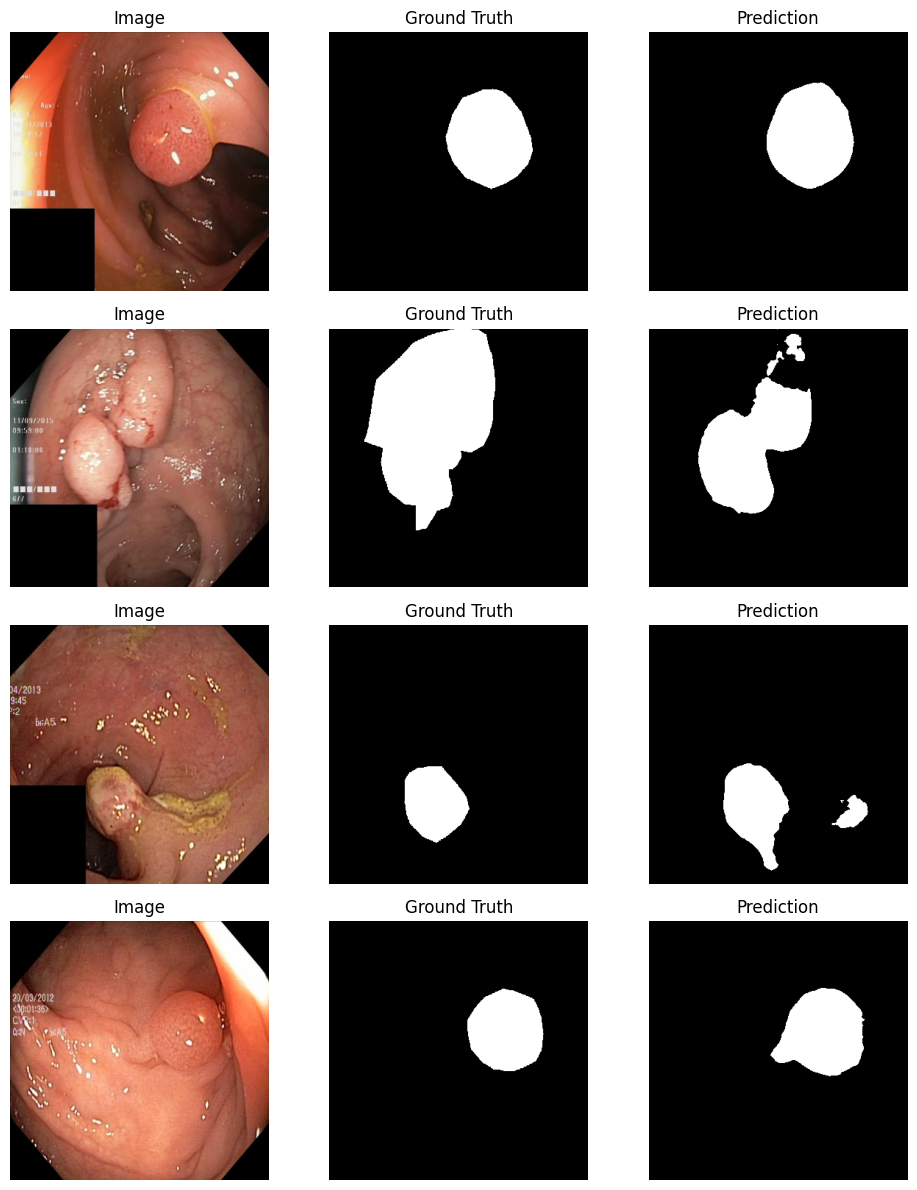

In [15]:
@torch.no_grad()
def visualise(model, dataset, n=4):
    model.eval()
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

    fig, axes = plt.subplots(n, 3, figsize=(10, n*3))
    for row in range(n):
        img, mask, _, _ = dataset[row]
        pred_logit = model(img.unsqueeze(0).to(DEVICE))[0][-1]
        pred = (torch.sigmoid(pred_logit) > 0.5).squeeze().cpu().float()

        img_show = (img * std + mean).permute(1,2,0).clamp(0,1).numpy()
        axes[row,0].imshow(img_show);                  axes[row,0].set_title("Image")
        axes[row,1].imshow(mask.squeeze(), cmap='gray'); axes[row,1].set_title("Ground Truth")
        axes[row,2].imshow(pred, cmap='gray');           axes[row,2].set_title("Prediction")
        for ax in axes[row]: ax.axis('off')

    plt.tight_layout()
    plt.show()

visualise(model, test_dataset, n=4)